In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm

# Classical Monty Hall: 3 doors, 1 open

<BarContainer object of 1 artists>

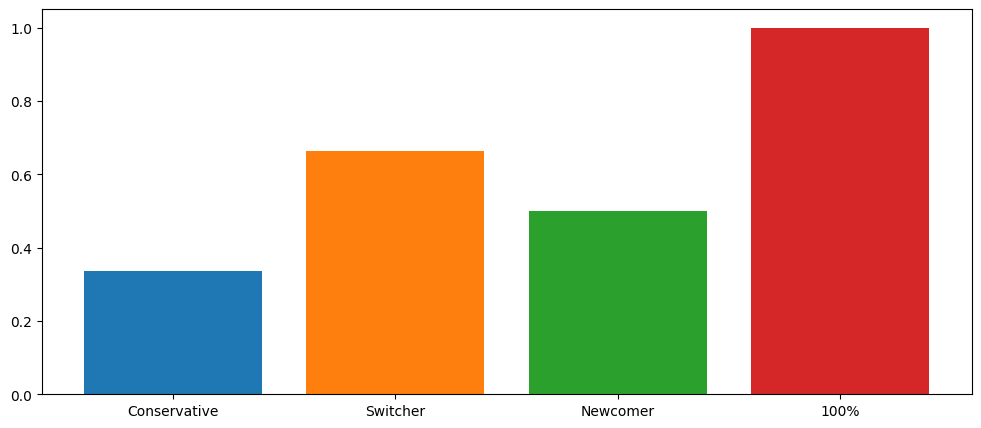

In [3]:
newcomer=np.array([])
switcher=np.array([])
conservative=np.array([])
N=3
p=1
Ngames=10000

def presenter_choice(N, doors_choice):
    presenter=np.random.randint(0,N-1)
    if doors_choice[presenter]==1:
        presenter=presenter_choice(N, doors_choice)
    return presenter

for i in range(Ngames):
    doors=np.zeros(N)
    wdoor=np.random.randint(0,N)
    doors[wdoor]=1

    choice=np.random.randint(0,N)
    doors_choice=np.delete(doors,choice)

    if choice==wdoor:
        conservative=np.append(conservative,1)
    else:
        conservative=np.append(conservative,0)

    b=choice
    a=N
    newcomer_doors=doors
    for j in range(p):
        presenter=presenter_choice(a, doors_choice)    
        doors_choice=np.delete(doors_choice,presenter)
        if b<=presenter:
            newcomer_doors=np.delete(newcomer_doors,presenter+1)
        if b>presenter:
            newcomer_doors=np.delete(newcomer_doors,presenter)
            b=b-1
        a=a-1
    
    if choice==wdoor:
        switcher=np.append(switcher,0)
    else:
        switcher_choice=np.random.randint(len(doors_choice))
        if doors_choice[switcher_choice]==1:
            switcher=np.append(switcher,1)
        else:
            switcher=np.append(switcher,0)

    newcomer_choice=np.random.randint(len(newcomer_doors))
    if newcomer_doors[newcomer_choice]==1:
        newcomer=np.append(newcomer,1)
    else:
        newcomer=np.append(newcomer,0)

cons=np.sum(conservative)
swi=np.sum(switcher)
new=np.sum(newcomer)

Pcons=np.sum(conservative)/Ngames
Pswi=np.sum(switcher)/Ngames
Pnew=np.sum(newcomer)/Ngames

plt.figure(figsize=[12,5])
plt.bar("Conservative",Pcons)
plt.bar("Switcher",Pswi)
plt.bar("Newcomer",Pnew)
plt.bar("100%",1)

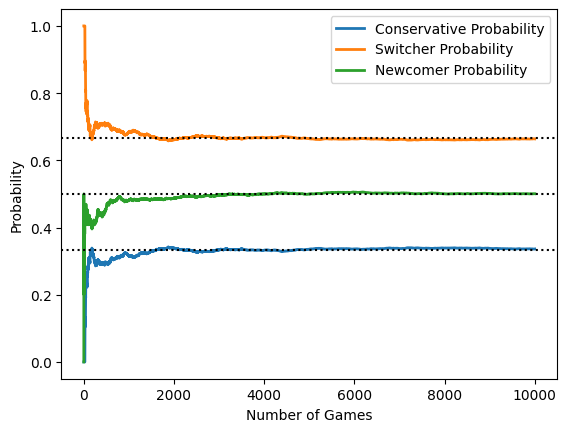

In [4]:
x=np.linspace(1,Ngames,Ngames)
cons_prob=np.array([])
swi_prob=np.array([])
new_prob=np.array([])

for i in range(len(x)):
    cons_prob=np.append(cons_prob,np.sum(conservative[x<=x[i]]) /x[i])
    swi_prob=np.append(swi_prob,np.sum(switcher[x<=x[i]]) /x[i])
    new_prob=np.append(new_prob,np.sum(newcomer[x<=x[i]]) /x[i])

plt.plot(x,cons_prob, label='Conservative Probability', lw=2)
plt.plot(x,swi_prob, label='Switcher Probability', lw=2)
plt.plot(x,new_prob, label='Newcomer Probability', lw=2)

plt.axhline(1/3, ls='dotted',c='black')
plt.axhline(2/3, ls='dotted',c='black')
plt.axhline(1/2, ls='dotted',c='black')

plt.ylabel("Probability")
plt.xlabel("Number of Games")

plt.legend(loc='upper right')

# Generalised Monty Hall: N doors {3,20}, p open {1,N-2}

In the generalised case with **N** doors and **p** opened, the probability of the switcher is

$$ p_{switch}=\frac{1}{N} \frac{N-1}{N-p-1} $$

In [5]:
Ngames=10000
Narray=np.array([])
parray=np.array([])
consarray=np.array([])
swiarray=np.array([])
newarray=np.array([])

for N in range(3,20):
    for p in range(1,N-2):

        Narray=np.append(Narray,N)
        parray=np.append(parray,p)
        
        newcomer=np.array([])
        switcher=np.array([])
        conservative=np.array([])
        
        
        for i in range(Ngames):
            doors=np.zeros(N)
            wdoor=np.random.randint(0,N)
            doors[wdoor]=1
        
            choice=np.random.randint(0,N)
            doors_choice=np.delete(doors,choice)
        
            if choice==wdoor:
                conservative=np.append(conservative,1)
            else:
                conservative=np.append(conservative,0)
        
            b=choice
            a=N
            newcomer_doors=doors
            for j in range(p):
                presenter=presenter_choice(a, doors_choice)    
                doors_choice=np.delete(doors_choice,presenter)
                if b<=presenter:
                    newcomer_doors=np.delete(newcomer_doors,presenter+1)
                if b>presenter:
                    newcomer_doors=np.delete(newcomer_doors,presenter)
                    b=b-1
                a=a-1
            
            if choice==wdoor:
                switcher=np.append(switcher,0)
            else:
                switcher_choice=np.random.randint(len(doors_choice))
                if doors_choice[switcher_choice]==1:
                    switcher=np.append(switcher,1)
                else:
                    switcher=np.append(switcher,0)
        
            newcomer_choice=np.random.randint(len(newcomer_doors))
            if newcomer_doors[newcomer_choice]==1:
                newcomer=np.append(newcomer,1)
            else:
                newcomer=np.append(newcomer,0)
        
        cons=np.sum(conservative)
        swi=np.sum(switcher)
        new=np.sum(newcomer)
        
        Pcons=np.sum(conservative)/Ngames
        Pswi=np.sum(switcher)/Ngames
        Pnew=np.sum(newcomer)/Ngames

        consarray=np.append(consarray,Pcons)
        swiarray=np.append(swiarray,Pswi)
        newarray=np.append(newarray,Pnew)

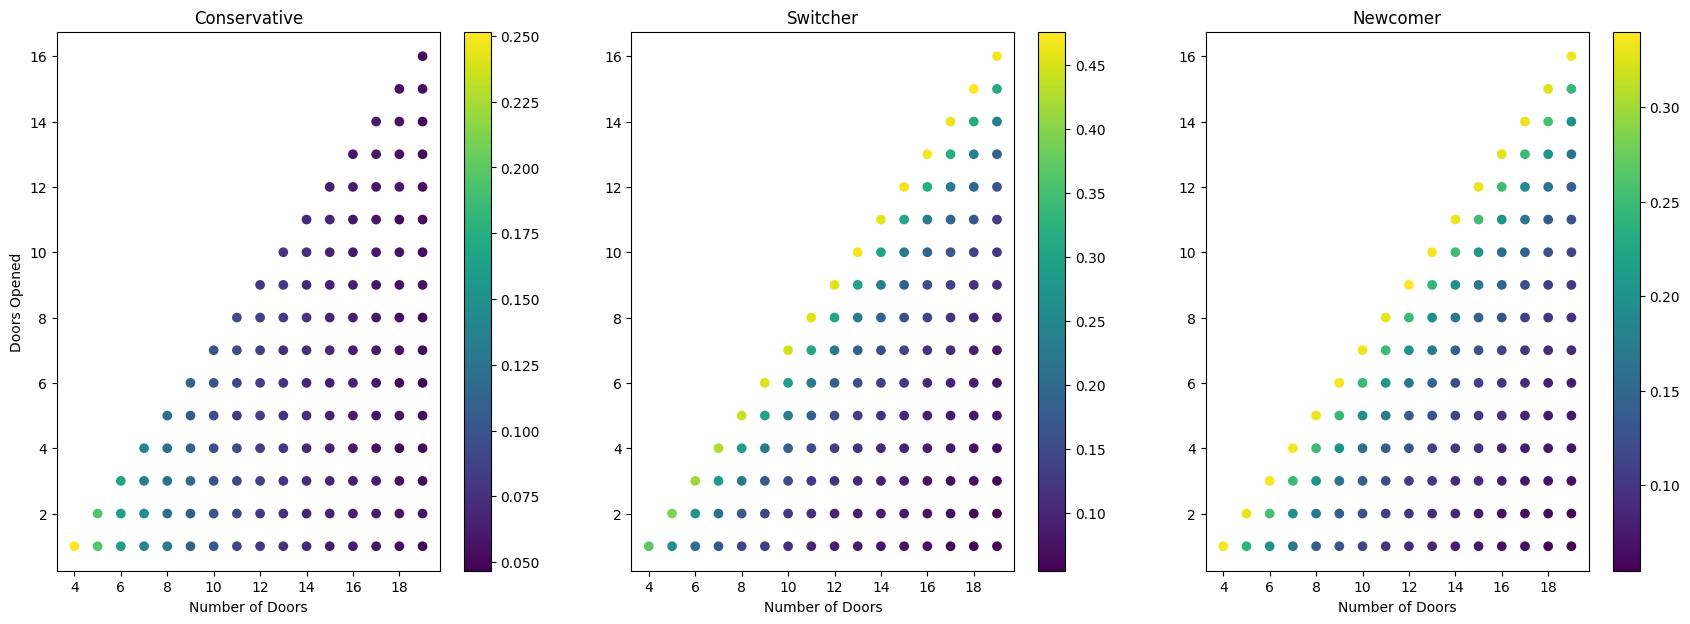

In [6]:
fig = plt.figure(figsize=(21, 7))
axs = fig.subplots(1, 3)

consmap=axs[0].scatter(Narray,parray, c=consarray, cmap='viridis')
swimap=axs[1].scatter(Narray,parray, c=swiarray, cmap='viridis')
newmap=axs[2].scatter(Narray,parray, c=newarray, cmap='viridis')
plt.colorbar(consmap)
plt.colorbar(swimap)
plt.colorbar(newmap)

axs[0].set_title("Conservative")
axs[1].set_title("Switcher")
axs[2].set_title("Newcomer")

axs[0].set_xlabel("Number of Doors")
axs[1].set_xlabel("Number of Doors")
axs[2].set_xlabel("Number of Doors")

axs[0].set_ylabel("Doors Opened");

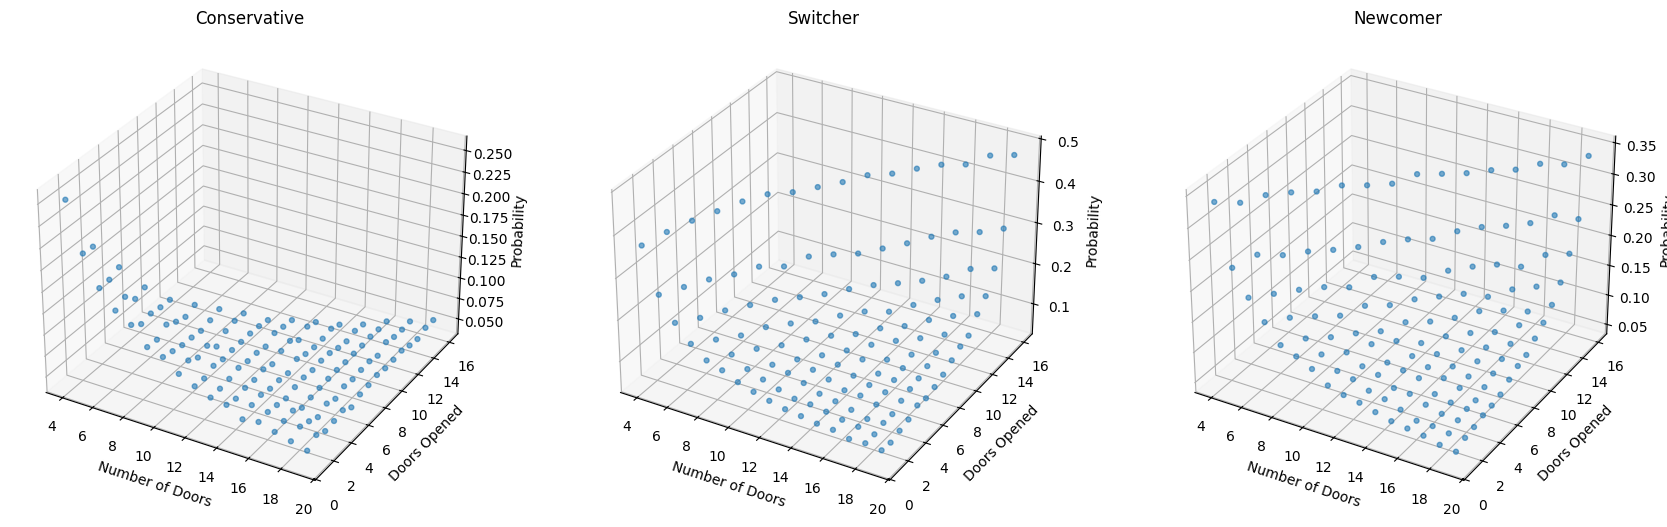

In [7]:
fig = plt.figure(figsize=(21, 7))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

ax1.scatter(Narray, parray, consarray, s=50, alpha=0.6, marker='.')
ax2.scatter(Narray, parray, swiarray, s=50, alpha=0.6, marker='.')
ax3.scatter(Narray, parray, newarray, s=50, alpha=0.6, marker='.')

ax1.set_title("Conservative")
ax2.set_title("Switcher")
ax3.set_title("Newcomer");

ax1.set_xlabel("Number of Doors")
ax2.set_xlabel("Number of Doors")
ax3.set_xlabel("Number of Doors")

ax1.set_ylabel("Doors Opened")
ax2.set_ylabel("Doors Opened")
ax3.set_ylabel("Doors Opened")

ax1.set_zlabel("Probability")
ax2.set_zlabel("Probability")
ax3.set_zlabel("Probability");